---

# FIGURE SIZES

---

>---
>You can adjust the **figure size** with the `figsize` argument

```python
    figsize=(width, height) # The default is 6.4 x 4.8 inches

```

In [3]:
def inch_to_cm(inch1:float, inch2:float):
    print(f"{inch1} inches = {inch1*2.54} cm")
    print(f"{inch2} inches = {inch2*2.54} cm")
    return None

inch_to_cm(6.4, 4.8)

6.4 inches = 16.256 cm
4.8 inches = 12.192 cm


<br>

---

<br>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [6]:
df = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin', 'period_end'])

df = (df
    .pivot_table(index='period_begin', 
                 columns='region_name', 
                 values='median_active_list_price', 
                 aggfunc='mean')
    .assign(CA_Average = lambda x: x.mean(axis=1))
    .resample('QE').mean().round()
     )

display(df.head(2), df.tail(2))
df.info()

region_name,Los Angeles,San Diego,San Francisco,CA_Average
period_begin,,,,
2017-03-31,630557.0,637701.0,1263499.0,843919.0
2017-06-30,650077.0,652195.0,1259083.0,853785.0


region_name,Los Angeles,San Diego,San Francisco,CA_Average
period_begin,,,,
2022-03-31,900615.0,885798.0,1293413.0,1026609.0
2022-06-30,906774.0,902425.0,1292479.0,1033893.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2017-03-31 to 2022-06-30
Freq: QE-DEC
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Los Angeles    22 non-null     float64
 1   San Diego      22 non-null     float64
 2   San Francisco  22 non-null     float64
 3   CA_Average     22 non-null     float64
dtypes: float64(4)
memory usage: 880.0 bytes


In [7]:
a = pd.to_datetime('1970-01-01')
b = pd.to_datetime('2017-03-01')
result1 = (b - a).days
print(f'Lower Limit: {result1}')

c = pd.to_datetime('1970-01-01')
d = pd.to_datetime('2022-07-31')
result2 = (d - c).days
print(f'Upper Limit: {result2}')

Lower Limit: 17226
Upper Limit: 19204


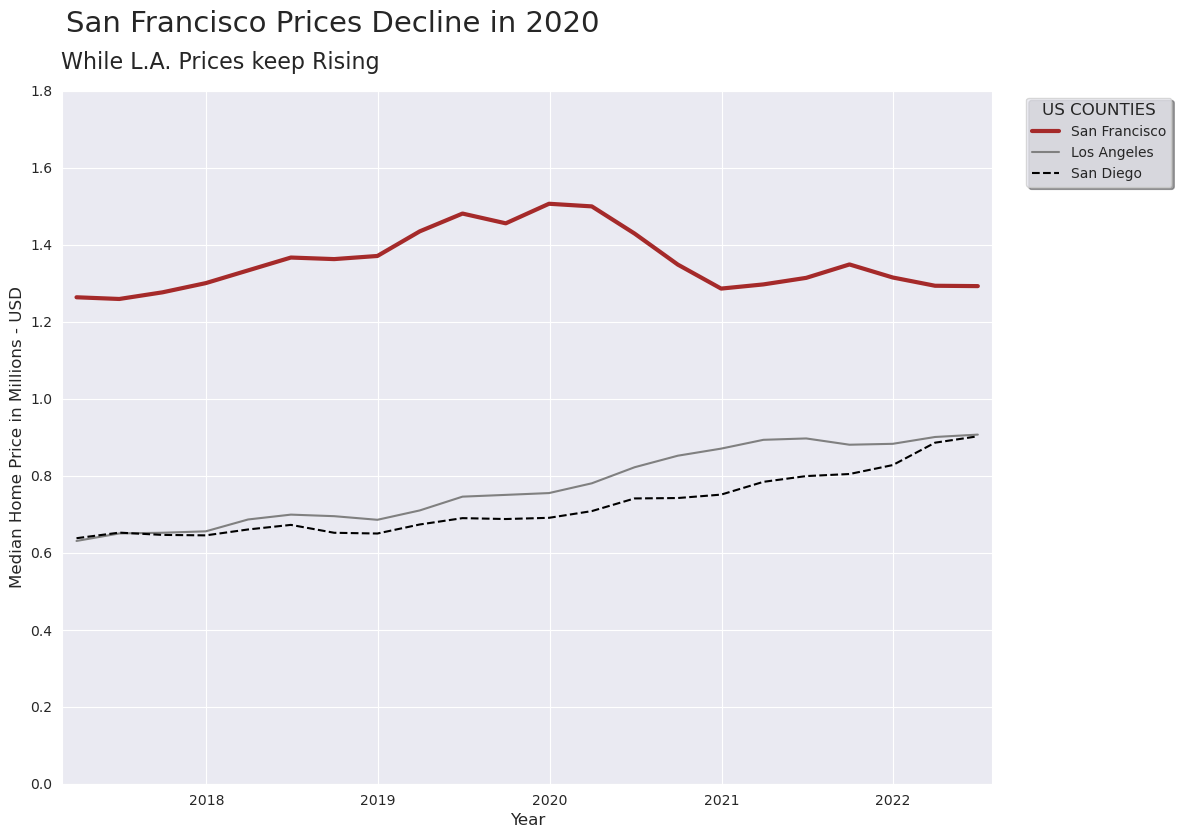

In [48]:
fig, ax = plt.subplots(figsize=(12, 9))
ax.plot(df['San Francisco']/1e6, 
        label='San Francisco',
        color='brown', linestyle='-', linewidth=3)

ax.plot(df['Los Angeles']/1e6, 
        label='Los Angeles',
        color='gray', linestyle='-', linewidth=1.5)

ax.plot(df['San Diego']/1e6, 
        label='San Diego',
        color='black', linestyle='--', linewidth=1.5)

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21, x=0.35, y=0.97)
ax.set_title('While L.A. Prices keep Rising', fontsize=16, x=0.17, y=1.02)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=12)
ax.legend(bbox_to_anchor=(1.2, 1),
          ncols=1,
          fancybox=True,
          shadow=True,
          framealpha=0.75,
          title='US COUNTIES',
          title_fontsize='large',
          fontsize='medium'
         )

ax.set_xlim(17226, 19204) # (2017-03-01, 2022-07-31) number of days since 1970-01-01
ax.set_ylim(0, 1.8) # y-axis units
plt.show()

---

`PRO TIP:` Be careful to first plot your line charts and then configure the `figsize` argument. Before starting to set up the titles and limits. Because those parameters depend on the size of the plot.

---